In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import Functions as f
import importlib
import numpy as np
import Filtering as fil
importlib.reload(f)
importlib.reload(fil)

<module 'Filtering' from '/Users/james/Desktop/DATA3001/Filtering.py'>

In [2]:
# Load datasets

f12024 = pd.read_csv('UNSW F12024.csv')
left = pd.read_csv('f1sim-ref-left.csv')
right = pd.read_csv('f1sim-ref-right.csv')
line = pd.read_csv('f1sim-ref-line.csv')
turns = pd.read_csv('f1sim-ref-turns.csv')

/var/folders/ng/t1t6hw391s14957cdp0_2k5c0000gn/T/ipykernel_9901/956444696.py:3: DtypeWarning: Columns (70,71,73,74,82) have mixed types. Specify dtype option on import or set low_memory=False.
  f12024 = pd.read_csv('UNSW F12024.csv')


In [3]:
df = f12024.copy()
print(df.shape)
df, left, right, line, turns = fil.filter_track_section(df, left, right, line, turns)
print(df.shape)
df = fil.keep_relevant_features(df)
print(df.shape)
df = fil.remove_nan(df)
print(df.shape)

(6525414, 89)
(769835, 89)
(769835, 12)
(673069, 12)


# Nonracing Behaviour
We analyse nonracing behaviour at the section relevent to our research. Non racing behaviour includes:
- Reversing
- Neutral Gear
- Slow Speed (threshold < 40km/h)

Naturally, analysing these features revealed examples indicative that something went wrong during the race. We safely remove them to not impact future analysis.


In [57]:
# Further sectioning
x_lower = 300
x_upper = 400
y_lower = 80
y_upper = 250

sdf = df[
        (df["M_WORLDPOSITIONX_1"].between(x_lower, x_upper)) &
        (df["M_WORLDPOSITIONY_1"].between(y_lower, y_upper))
    ]

# Reversing Example

In [58]:
reverse = sdf[sdf["M_GEAR_1"] == -1]

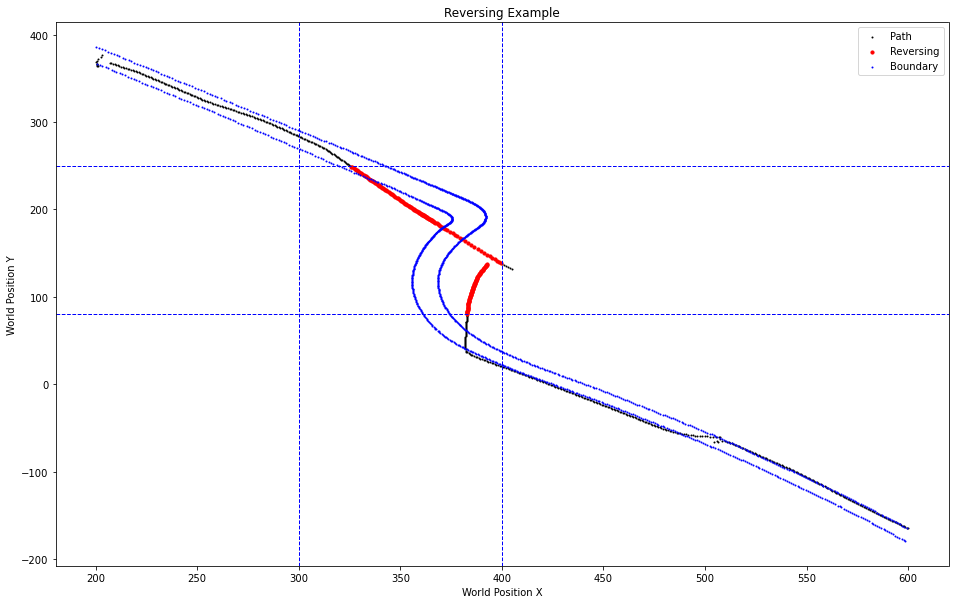

In [71]:
# Reversing Example
example_session = '22C5995B57B8C155E0631518000AD50E'
example_lap = 1

example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]
example_r = reverse[(reverse["SESSION_GUID"] == example_session) & (reverse['M_CURRENTLAPNUM'] == example_lap)]

plt.figure(figsize=(16, 10))
plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")
plt.scatter(example_r['M_WORLDPOSITIONX_1'], example_r['M_WORLDPOSITIONY_1'], color="red", s=10, label="Reversing")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.legend()
plt.title("Reversing Example")
plt.xlabel("World Position X")
plt.ylabel("World Position Y")

plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_lower, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_upper, color='blue', linestyle='--', linewidth=1)


plt.show()

# Neutral Example

In [62]:
neutral = sdf[sdf["M_GEAR_1"] == 0]

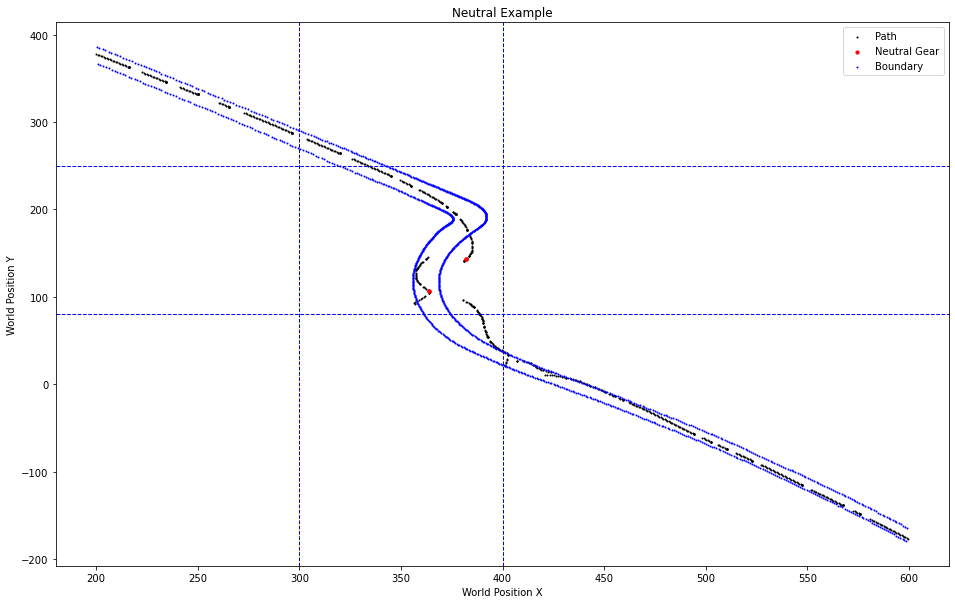

In [89]:
# Neutral Example
example_session = '27DADF09524A1D00E0631818000AC0D3'
example_lap = 2

example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]
example_n = neutral[(neutral["SESSION_GUID"] == example_session) & (neutral['M_CURRENTLAPNUM'] == example_lap)]

plt.figure(figsize=(16, 10))
plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")
plt.scatter(example_n['M_WORLDPOSITIONX_1'], example_n['M_WORLDPOSITIONY_1'], color="red", s=10, label="Neutral Gear")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.legend()
plt.title("Neutral Example")
plt.xlabel("World Position X")
plt.ylabel("World Position Y")

plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_lower, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_upper, color='blue', linestyle='--', linewidth=1)


plt.show()

# Slow Example

In [79]:
slow = sdf[sdf["M_SPEED_1"] <= 30]

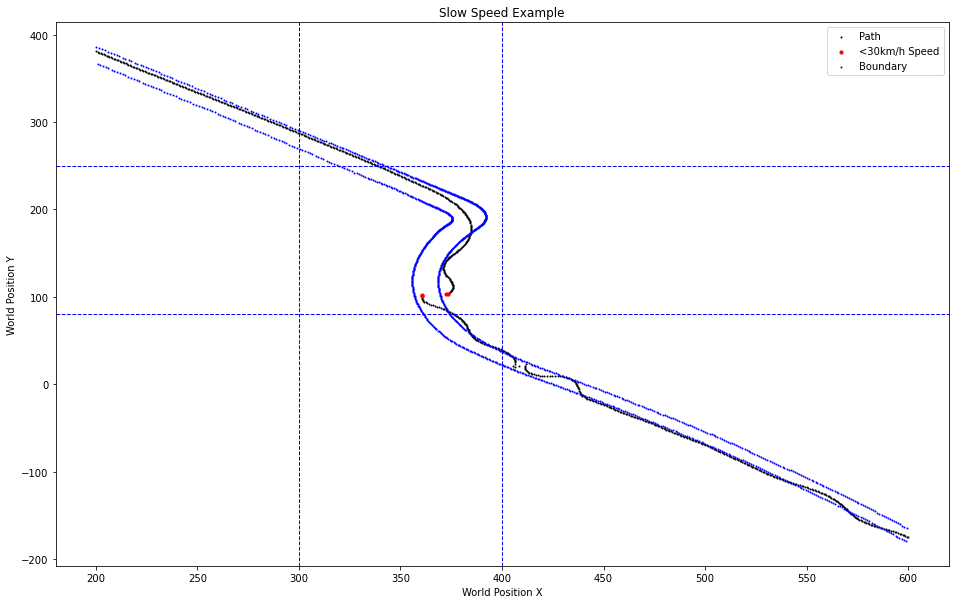

In [91]:
# Slow Example
example_session = '306846828689AEA2E0631218000A2ACF'
example_lap = 4

example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]
example_s = slow[(slow["SESSION_GUID"] == example_session) & (slow['M_CURRENTLAPNUM'] == example_lap)]

plt.figure(figsize=(16, 10))
plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")
plt.scatter(example_s['M_WORLDPOSITIONX_1'], example_s['M_WORLDPOSITIONY_1'], color="red", s=10, label="<30km/h Speed")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.legend()
plt.title("Slow Speed Example")
plt.xlabel("World Position X")
plt.ylabel("World Position Y")

plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_lower, color='blue', linestyle='--', linewidth=1)
plt.axhline(y_upper, color='blue', linestyle='--', linewidth=1)


plt.show()